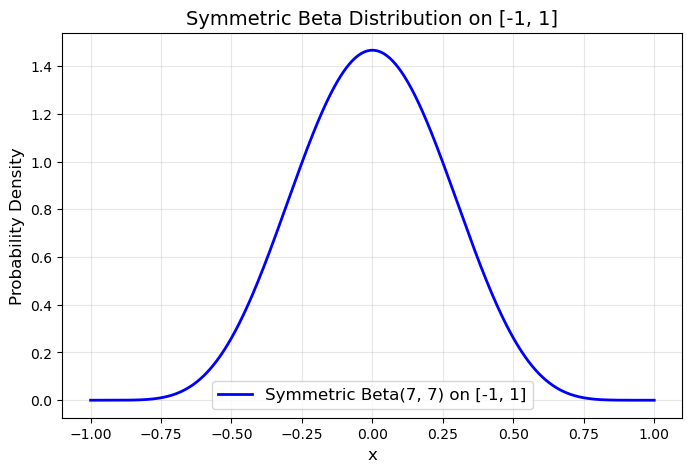

Variance of the scaled Beta distribution: 0.06666666666666667
95% probability range: [-0.4973, 0.4973]
99.7% probability range: [-0.6916, 0.6916]


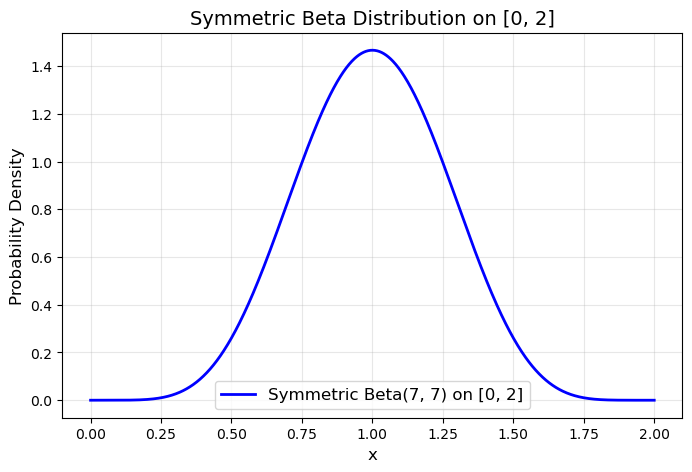

Variance of the scaled Beta distribution: 0.06666666666666667
95% probability range: [0.5027, 1.4973]
99.7% probability range: [0.3084, 1.6916]


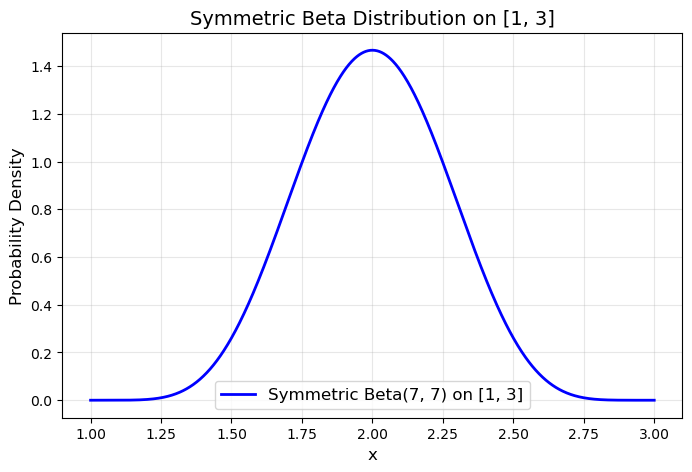

Variance of the scaled Beta distribution: 0.06666666666666667
95% probability range: [1.5027, 2.4973]
99.7% probability range: [1.3084, 2.6916]


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def scaled_beta_distribution_with_probability_ranges(a, b, alpha):
    """
    Scales a symmetric Beta(alpha, alpha) distribution to the range [a, b],
    visualizes it, prints the variance of the scaled distribution, and provides
    the range of values that occupy 95% and 99.7% of the probability.
    
    Parameters:
    - a (float): Lower bound of the scale range.
    - b (float): Upper bound of the scale range.
    - alpha (float): Parameter for the symmetric Beta(alpha, alpha).
    """
    # Generate x values for the scaled range
    x_scaled = np.linspace(a, b, 1000)
    
    # Scale the Beta PDF
    beta_pdf_scaled = (1 / (b - a)) * beta.pdf((x_scaled - a) / (b - a), alpha, alpha)
    
    # Plot the scaled Beta distribution
    plt.figure(figsize=(8, 5))
    plt.plot(x_scaled, beta_pdf_scaled, label=f'Symmetric Beta({alpha}, {alpha}) on [{a}, {b}]', linewidth=2, color='blue')
    plt.title(f'Symmetric Beta Distribution on [{a}, {b}]', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12)
    plt.show()
    
    # Compute the variance of the scaled Beta distribution
    original_variance = alpha * alpha / ((2 * alpha) ** 2 * (2 * alpha + 1))  # Variance of Beta(alpha, alpha)
    scaled_variance = original_variance * (b - a) ** 2  # Variance of the scaled distribution
    print(f"Variance of the scaled Beta distribution: {scaled_variance}")
    
    # Compute the range for 95% and 99.7% probability
    lower_95 = a + (b - a) * beta.ppf(0.025, alpha, alpha)
    upper_95 = a + (b - a) * beta.ppf(0.975, alpha, alpha)
    lower_997 = a + (b - a) * beta.ppf(0.0015, alpha, alpha)
    upper_997 = a + (b - a) * beta.ppf(0.9985, alpha, alpha)
    
    print(f"95% probability range: [{lower_95:.4f}, {upper_95:.4f}]")
    print(f"99.7% probability range: [{lower_997:.4f}, {upper_997:.4f}]")

# Example usage

scaled_beta_distribution_with_probability_ranges(-1, 1, 7)
scaled_beta_distribution_with_probability_ranges(0, 2, 7)
scaled_beta_distribution_with_probability_ranges(1, 3, 7)


--- Simulation Results for Magnitude-Weighted Distances ---
   Dimensionality  No_Normalization  Dim_Based  Empirical_Variance    ZScore
0               2         10.297594   7.281499            5.810031  1.414214
1               3         14.044593   8.108649            2.719243  1.732051
2               4         16.147556   8.073778            2.646381  2.000000
3               5         18.175934   8.128525            2.668508  2.236068
4               6         19.929604   8.136227            2.866289  2.449490
5               7         21.570965   8.153059            2.920218  2.645751
6               8         23.561239   8.330156            3.091727  2.828427
7               9         24.536437   8.178812            3.274014  3.000000
8              10         26.960063   8.525521            3.395614  3.162278


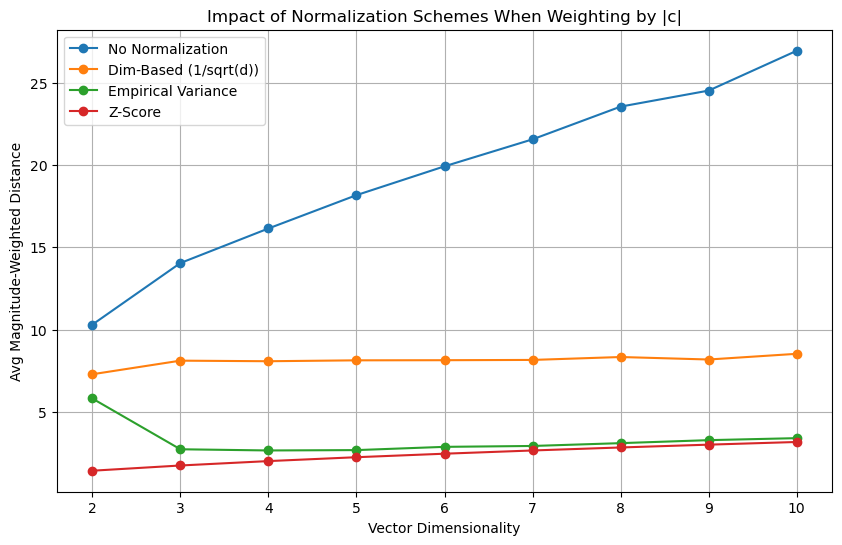

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# 1) Distance Functions
# ------------------------

def distance_c_weighted_no_normalization(v, c):
    """
    Raw version:
    D(v,c) = sqrt( sum_i (|c_i| * (v_i - c_i)^2 ) ).
    """
    # If c_i is 1D, then "magnitude" is just abs(c_i).
    # If c_i can be negative, use abs(c_i).
    # For multi-D issues, you'd have to define ||c_i|| in vector sense.
    weights = np.abs(c)  # or c if always positive
    return np.sqrt(np.sum(weights * (v - c)**2))


def distance_c_weighted_dim_based(v, c):
    """
    D(v,c) / sqrt(d).
    """
    d = len(v)
    base_dist = distance_c_weighted_no_normalization(v, c)
    return base_dist / np.sqrt(d)

def distance_c_weighted_empirical_variance(v, c):
    """
    1) Construct a weighted difference array: wdiff_i = sqrt(|c_i|)*(v_i - c_i).
    2) Then standardize wdiff_i by its own std dev.
    """
    # Weighted difference first:
    wdiff = np.sqrt(np.abs(c)) * (v - c)
    std_ = np.std(wdiff)
    if std_ == 0.0:
        return 0.0
    return np.linalg.norm(wdiff / std_)

def distance_c_weighted_zscore(v, c):
    """
    Approach:
    1) Weighted difference: wdiff_i = sqrt(|c_i|)*(v_i - c_i).
    2) Then do z-score across coordinates of wdiff.
    """
    wdiff = np.sqrt(np.abs(c)) * (v - c)
    mean_ = np.mean(wdiff)
    std_ = np.std(wdiff)
    if std_ == 0.0:
        return 0.0
    z = (wdiff - mean_)/std_
    return np.linalg.norm(z)

# ---------------------------------
# 2) Simulation & Analysis
# ---------------------------------

def simulate_and_analyze(v_dims, num_simulations=1000):
    records = []
    for dim in v_dims:
        dist_none_list = []
        dist_dim_list = []
        dist_var_list = []
        dist_z_list = []
        
        for _ in range(num_simulations):
            # Generate random vectors v, c
            v = np.random.uniform(1, 10, dim)
            c = np.random.uniform(1, 10, dim)
            
            # Compute the c-weighted distances with different normalizations
            d_none = distance_c_weighted_no_normalization(v, c)
            d_dim = distance_c_weighted_dim_based(v, c)
            d_var = distance_c_weighted_empirical_variance(v, c)
            d_z = distance_c_weighted_zscore(v, c)
            
            dist_none_list.append(d_none)
            dist_dim_list.append(d_dim)
            dist_var_list.append(d_var)
            dist_z_list.append(d_z)
        
        # Summarize
        records.append({
            "Dimensionality": dim,
            "No_Normalization": np.mean(dist_none_list),
            "Dim_Based": np.mean(dist_dim_list),
            "Empirical_Variance": np.mean(dist_var_list),
            "ZScore": np.mean(dist_z_list)
        })
    
    return pd.DataFrame(records)


def main():
    vector_dimensions = range(2, 11)  # from 2 to 10
    sim_results = simulate_and_analyze(vector_dimensions, num_simulations=1000)
    
    print("--- Simulation Results for Magnitude-Weighted Distances ---")
    print(sim_results)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(sim_results["Dimensionality"], sim_results["No_Normalization"], label="No Normalization", marker='o')
    plt.plot(sim_results["Dimensionality"], sim_results["Dim_Based"], label="Dim-Based (1/sqrt(d))", marker='o')
    plt.plot(sim_results["Dimensionality"], sim_results["Empirical_Variance"], label="Empirical Variance", marker='o')
    plt.plot(sim_results["Dimensionality"], sim_results["ZScore"], label="Z-Score", marker='o')
    
    plt.xlabel("Vector Dimensionality")
    plt.ylabel("Avg Magnitude-Weighted Distance")
    plt.title("Impact of Normalization Schemes When Weighting by |c|")
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()


In [79]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import time

# Step 1: Generate random points in R^15
n_samples = 1_000_000  # Number of points
n_features = 15        # Dimensions (R^15)
data = np.random.random((n_samples, n_features))

# Step 2: Subsample the data
subsample_size = 1_000
np.random.seed(42)
subsample = data[np.random.choice(data.shape[0], subsample_size, replace=False)]

# Step 3: Standardize the data
scaler = StandardScaler()
subsample = scaler.fit_transform(subsample)

# Step 4: Evaluate K-means and compute information criteria
def evaluate_kmeans(data, max_clusters):
    results = []
    for n_clusters in range(1, max_clusters + 1):
        # Fit KMeans
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto', max_iter=300)
        kmeans.fit(data)

        # Compute Gaussian Mixture for AIC/BIC
        gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
        gmm.fit(data)

        # Calculate AIC and BIC
        aic = gmm.aic(data)
        bic = gmm.bic(data)

        # Store results
        results.append((n_clusters, kmeans.inertia_, aic, bic))
    return results

# Step 5: Run evaluation for 1 to 10 clusters
max_clusters = 10
start_time = time.time()
results = evaluate_kmeans(subsample, max_clusters)
end_time = time.time()

# Step 6: Analyze results
print(f"Evaluation completed in {end_time - start_time:.2f} seconds")
print("Clusters | Inertia (KMeans) | AIC (GMM) | BIC (GMM)")
for n_clusters, inertia, aic, bic in results:
    print(f"{n_clusters:8d} | {inertia:16.2f} | {aic:9.2f} | {bic:9.2f}")


Evaluation completed in 9.17 seconds
Clusters | Inertia (KMeans) | AIC (GMM) | BIC (GMM)
       1 |         15000.00 |  42724.65 |  43387.19
       2 |         14236.80 |  42694.72 |  44024.73
       3 |         13663.46 |  42726.10 |  44723.56
       4 |         13276.16 |  42752.95 |  45417.86
       5 |         12845.11 |  42891.07 |  46223.44
       6 |         12522.14 |  42761.36 |  46761.18
       7 |         12276.49 |  42704.04 |  47371.31
       8 |         12026.78 |  42936.98 |  48271.71
       9 |         11824.57 |  42921.96 |  48924.14
      10 |         11644.02 |  42959.09 |  49628.73
